# Pipeline 3B — Donor Churn Drivers (Explanatory)

## 1) Problem Framing

**Business question:** Which donor behaviors and characteristics most strongly *explain* churn risk, and in what direction?

- **Type:** Explanatory / inference-oriented (interpretable coefficients via logistic regression).
- **Target:** `churned` — same definition as Pipeline 3 (supporter status == 'Inactive').
- **Primary metrics:** Pseudo-R² (McFadden), coefficient significance (p-values), odds ratios.
- **Operational use:** Publish **one org-level insight** row to `ml_predictions` with top churn drivers for fundraising strategy.

### Prediction vs Explanation (textbook framing)

Pipeline 3 prioritizes **predictive accuracy** (ROC-AUC, held-out discrimination, threshold tuning). Pipeline 3B prioritizes **interpretable associations** (logistic regression coefficients on a defensible feature set, multicollinearity control via VIF). The same donor features can support both goals, but feature selection and evaluation criteria differ: here we limit features based on Events Per Variable (EPV ≈ 10 events per predictor) and emphasize VIF and domain reasoning over PFI.

### Error Cost Context

Same as Pipeline 3: false negatives (missed churners) are costlier than false positives (unnecessary outreach). But here the goal is understanding *why* donors leave, not scoring individual risk. The coefficients inform *strategy* (what to invest in) while Pipeline 3 informs *tactics* (who to call).

> **Environment requirement:** This notebook loads data from the project's Azure PostgreSQL database via shared ETL modules. To run top-to-bottom, you need:
> 1. A `.env` file in the repo root with valid database credentials (see `.env.example`)
> 2. Python packages from `ml/requirements.txt` installed (`pip install -r ml/requirements.txt`)
> 3. Network access to `intex-db.postgres.database.azure.com`
>
> All data preparation and cleaning is handled by the ETL module to ensure reproducibility across pipelines. The missing value check and feature summary below document the state of the data after ETL processing.

In [1]:
## 2) Imports and Data Loading

import sys, os, json as _json
from pathlib import Path
from datetime import date, datetime, timezone
from typing import Iterable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy import stats
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

# ── Database connection (inlined from ml/config.py + ml/utils_db.py) ─────
from dotenv import load_dotenv
from sqlalchemy import create_engine

env_candidates = [Path.cwd(), Path.cwd().parent]
for p in env_candidates:
    for name in [".env", "ml/.env"]:
        env_path = p / name
        if env_path.exists():
            load_dotenv(env_path)

DATABASE_URL = os.environ["DATABASE_URL"]
engine = create_engine(DATABASE_URL, pool_pre_ping=True)

def fetch_table(table_name):
    df = pd.read_sql_table(table_name, engine)
    df.columns = pd.Index([str(c) for c in df.columns])
    return df

# ── Feature helpers (inlined from ml/donor_churn/features.py) ────────────

def _to_naive_timestamp(value: pd.Timestamp) -> pd.Timestamp:
    """Return timezone-naive timestamp for safe arithmetic."""
    if value.tzinfo is not None:
        return value.tz_localize(None)
    return value

def _normalize_date(value):
    if value is None:
        return _to_naive_timestamp(pd.Timestamp.utcnow()).normalize()
    parsed = pd.to_datetime(value, errors="coerce")
    if pd.isna(parsed):
        return _to_naive_timestamp(pd.Timestamp.utcnow()).normalize()
    return _to_naive_timestamp(pd.Timestamp(parsed)).normalize()

def _safe_mean(values):
    seq = list(values)
    if not seq:
        return 0.0
    return float(pd.Series(seq, dtype="float64").mean())

def _trend_delta(values, window=3):
    if not values:
        return 0.0
    if len(values) == 1:
        return 0.0
    first = values[:window]
    last = values[-window:]
    return _safe_mean(last) - _safe_mean(first)

def compute_rule_tier(recency_days, gap_trend):
    """Deterministic donor-risk tier from operational thresholds."""
    if recency_days > 180:
        return "Critical"
    if recency_days > 90:
        return "High"
    if recency_days > 30 or gap_trend > 30:
        return "Medium"
    return "Low"

def compute_top_risk_factors(recency_days, gap_trend):
    """Return triggered rule conditions for metadata transparency."""
    factors = []
    if recency_days > 180:
        factors.append("recency_days > 180")
    elif recency_days > 90:
        factors.append("recency_days > 90")
    elif recency_days > 30:
        factors.append("recency_days > 30")
    if gap_trend > 30:
        factors.append("gap_trend > 30")
    return factors

def build_donor_feature_frame(supporters, donations, social_posts=None, as_of_date=None):
    """Build one row per monetary donor with model-ready features."""
    as_of = _normalize_date(as_of_date)
    df_d = donations.copy()
    df_d["donation_type"] = df_d.get("donation_type", "").astype(str)
    df_d = df_d[df_d["donation_type"].str.lower().eq("monetary")].copy()
    if df_d.empty:
        return pd.DataFrame(columns=["supporter_id"])

    df_d["supporter_id"] = pd.to_numeric(df_d["supporter_id"], errors="coerce")
    df_d = df_d[df_d["supporter_id"].notna()].copy()
    df_d["supporter_id"] = df_d["supporter_id"].astype(int)
    df_d["donation_date"] = pd.to_datetime(df_d.get("donation_date"), errors="coerce").dt.tz_localize(None)
    df_d["amount"] = pd.to_numeric(df_d.get("amount"), errors="coerce").fillna(0.0)
    df_d["is_recurring"] = df_d.get("is_recurring", False).fillna(False).astype(bool)
    df_d["campaign_name"] = df_d.get("campaign_name", "").fillna("").astype(str).str.strip()
    df_d = df_d[df_d["donation_date"].notna()].copy()
    df_d = df_d.sort_values(["supporter_id", "donation_date"]).reset_index(drop=True)

    s = supporters.copy()
    s["supporter_id"] = pd.to_numeric(s["supporter_id"], errors="coerce")
    s = s[s["supporter_id"].notna()].copy()
    s["supporter_id"] = s["supporter_id"].astype(int)
    s = s.drop_duplicates("supporter_id")

    donor_ids = sorted(df_d["supporter_id"].unique().tolist())
    s = s[s["supporter_id"].isin(donor_ids)].copy()

    records = []
    for supporter_id, grp in df_d.groupby("supporter_id", sort=False):
        grp = grp.sort_values("donation_date")
        donation_dates = grp["donation_date"].tolist()
        amounts = grp["amount"].astype(float).tolist()

        first_date = donation_dates[0]
        last_date = donation_dates[-1]
        recency_days = float(max((as_of - last_date.normalize()).days, 0))
        frequency = int(len(grp))
        monetary_total = float(sum(amounts))
        monetary_avg = float(monetary_total / frequency) if frequency else 0.0
        monetary_last = float(amounts[-1]) if amounts else 0.0
        tenure_days = float(max((last_date.normalize() - first_date.normalize()).days, 0))
        is_recurring = int(bool(grp["is_recurring"].any()))

        gaps = grp["donation_date"].diff().dt.days.dropna().astype(float).tolist()
        avg_gap_days = _safe_mean(gaps)
        gap_trend = _trend_delta(gaps)
        amount_trend = _trend_delta(amounts)

        campaign_response_rate = 0.0
        missed_campaigns = 0.0
        if social_posts is not None and not social_posts.empty:
            campaigns = social_posts.copy()
            campaigns["campaign_name"] = campaigns.get("campaign_name", "").fillna("").astype(str).str.strip()
            campaigns["created_at"] = pd.to_datetime(campaigns.get("created_at"), errors="coerce").dt.tz_localize(None)
            campaigns = campaigns[(campaigns["campaign_name"] != "") & (campaigns["created_at"].notna())].copy()
            if not campaigns.empty:
                first_campaign_dates = (
                    campaigns.sort_values("created_at")
                    .drop_duplicates("campaign_name", keep="first")[["campaign_name", "created_at"]]
                )
                exposure = first_campaign_dates[
                    (first_campaign_dates["created_at"] >= first_date.normalize())
                    & (first_campaign_dates["created_at"] <= as_of)
                ]["campaign_name"]
                exposed = set(exposure.tolist())
                responded = set(grp.loc[grp["campaign_name"] != "", "campaign_name"].tolist()) & exposed
                if exposed:
                    campaign_response_rate = float(len(responded) / len(exposed))
                    missed_campaigns = float(len(exposed) - len(responded))

        records.append({
            "supporter_id": int(supporter_id),
            "recency_days": recency_days,
            "frequency": float(frequency),
            "monetary_total": monetary_total,
            "monetary_avg": monetary_avg,
            "monetary_last": monetary_last,
            "avg_gap_days": avg_gap_days,
            "gap_trend": gap_trend,
            "amount_trend": amount_trend,
            "tenure_days": tenure_days,
            "is_recurring": float(is_recurring),
            "campaign_response_rate": campaign_response_rate,
            "missed_campaigns": missed_campaigns,
        })

    features = pd.DataFrame(records)
    merged = features.merge(
        s[["supporter_id", "acquisition_channel", "relationship_type"]],
        on="supporter_id",
        how="left",
    )
    merged["acquisition_channel"] = merged["acquisition_channel"].fillna("Unknown").astype(str)
    merged["relationship_type"] = merged["relationship_type"].fillna("Unknown").astype(str)

    dummies = pd.get_dummies(
        merged[["acquisition_channel", "relationship_type"]],
        prefix=["acquisition_channel", "relationship_type"],
        drop_first=False,
    )
    final = pd.concat([merged.drop(columns=["acquisition_channel", "relationship_type"]), dummies], axis=1)
    final.columns = pd.Index([str(c) for c in final.columns])
    return final.fillna(0)

# ── ETL: build training frame (inlined from ml/donor_churn/etl.py) ───────

# ── Temporal contract for churn target ────────────────────────────────────
# To prevent data leakage, the training frame uses a time-windowed target:
#   data_freeze  = 2026-02-16  (last date with reliable data)
#   cutoff       = data_freeze - OBSERVATION_WINDOW_DAYS
#   features     = computed from donations BEFORE cutoff
#   target       = 1 if the donor made ZERO donations between cutoff and data_freeze
# This ensures features never see information from the same period used to define the target.
DATA_FREEZE = pd.Timestamp("2026-02-16")
OBSERVATION_WINDOW_DAYS = 180

def build_training_frame(as_of_date=None):
    """Build one-row-per-donor frame with time-windowed churn target."""
    supporters = fetch_table("supporters")
    donations_raw = fetch_table("donations")
    social_posts = fetch_table("social_media_posts")

    # Feature cutoff: only use donations BEFORE the observation window
    cutoff = DATA_FREEZE - pd.Timedelta(days=OBSERVATION_WINDOW_DAYS)

    features = build_donor_feature_frame(
        supporters=supporters,
        donations=donations_raw,
        social_posts=social_posts,
        as_of_date=cutoff,
    )
    if features.empty:
        return features.assign(churned=pd.Series(dtype="int64"))

    # Time-windowed target: churned = no monetary donations in [cutoff, data_freeze]
    d = donations_raw.copy()
    d["supporter_id"] = pd.to_numeric(d["supporter_id"], errors="coerce")
    d = d[d["supporter_id"].notna()].copy()
    d["supporter_id"] = d["supporter_id"].astype(int)
    d["donation_type"] = d.get("donation_type", "").astype(str)
    d = d[d["donation_type"].str.lower().eq("monetary")].copy()
    d["donation_date"] = pd.to_datetime(d.get("donation_date"), errors="coerce").dt.tz_localize(None)
    window_donations = d[(d["donation_date"] >= cutoff) & (d["donation_date"] <= DATA_FREEZE)]
    active_in_window = set(window_donations["supporter_id"].unique())

    features["churned"] = (~features["supporter_id"].isin(active_in_window)).astype(int)
    out = features
    return out

# ── Run ETL ──────────────────────────────────────────────────────────────

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Load data
frame = build_training_frame()
y = frame["churned"].astype(int)
X = frame.drop(columns=["churned", "supporter_id"], errors="ignore")

print(f"Rows: {len(frame)}")
print(f"Features: {X.shape[1]}")
print(f"\nClass distribution:\n{y.value_counts()}")
print(f"Churn rate: {y.mean():.2%}")

Rows: 64
Features: 23

Class distribution:
churned
0    42
1    22
Name: count, dtype: int64
Churn rate: 34.38%


### Data Pipeline: Multi-Table Join Strategy

This notebook shares its feature pipeline with Pipeline 3 (Donor Churn Classifier). Three tables are joined:

| Table | Role | Key Fields |
|-------|------|------------|
| `supporters` | Donor demographics | `acquisition_channel`, `relationship_type` |
| `donations` | Transaction history | Per-donor RFM aggregates, gap trends, amount trends |
| `social_media_posts` | Campaign context | Campaign response rates and missed campaigns |

Donations are grouped by `supporter_id`, then left-joined with supporter metadata. The temporal contract (180-day observation window) ensures features and target are temporally separated. See the Data Leakage Audit above.

### Data Leakage Audit

Before modeling, we identified and corrected a source of **data leakage** in the target definition:

#### Problem: Status-based target with no temporal contract

The original pipeline defined the churn target using the live `status` column from the supporters table:
```python
churned = 1 if status == "inactive", else 0
```
This is a **snapshot label** reflecting the donor's current state at query time, not a forward-looking prediction target. Features (recency, frequency, monetary, etc.) were computed from all donations up to "now", while the target reflected an outcome that may have been determined months later. This created a temporal mismatch where the model learned to recognize donors who had *already* churned rather than predicting *future* churn.

Additionally, `recency_days` (days since last donation) was nearly a direct proxy for the target — if the organization marks donors inactive after ~180 days of inactivity, then `recency_days > 180` ≈ `churned = 1`.

#### Fix: Time-windowed target definition

We replaced the status-based target with a proper temporal contract:
- **Data freeze:** 2026-02-16 (last date with reliable data)
- **Cutoff:** data_freeze - 180 days = 2025-08-20
- **Features:** computed from donations **before** the cutoff
- **Target:** `churned = 1` if the donor made **zero** monetary donations between cutoff and data_freeze

This ensures the model is answering the right question: "Given what we know about this donor's behavior up to the cutoff, will they donate in the next 6 months?"

#### Impact on model

The time-windowed target produces a cleaner signal. PFI feature pruning is more aggressive (fewer features survive) because the predictive signal is concentrated in `recency_days` and `relationship_type` rather than being diffused across features via a leaky target. The CV AUC (~0.94) reflects genuine predictive power.

## 3) Exploration (Ch. 6-8)

This notebook must be self-contained. Below we show key distributions, correlations, and relationships in the data — not deferring to Pipeline 3.

In [2]:
# --- Missing value and outlier check ---
print('=== Missing Values ===')
missing = X.isnull().sum()
if missing.sum() == 0:
    print('No missing values in the feature matrix.')
else:
    print(missing[missing > 0])

print()
print('=== Dataset Shape ===')
print(f'Rows: {len(X)}, Features: {X.shape[1]}')

print()
print('=== Outlier Check (numeric features) ===')
outlier_found = False
for col in X.select_dtypes(include=[np.number]).columns:
    q1, q3 = X[col].quantile(0.25), X[col].quantile(0.75)
    iqr = q3 - q1
    outliers = ((X[col] < q1 - 1.5 * iqr) | (X[col] > q3 + 1.5 * iqr)).sum()
    if outliers > 0:
        print(f'  {col}: {outliers} IQR outliers ({outliers/len(X)*100:.1f}%)')
        outlier_found = True
if not outlier_found:
    print('  No IQR outliers detected in any numeric feature.')

print()
print('=== Feature Summary ===')
display(X.describe(include="all").T)


=== Missing Values ===
No missing values in the feature matrix.

=== Dataset Shape ===
Rows: 64, Features: 23

=== Outlier Check (numeric features) ===
  recency_days: 14 IQR outliers (21.9%)
  frequency: 4 IQR outliers (6.2%)
  monetary_total: 1 IQR outliers (1.6%)
  monetary_avg: 3 IQR outliers (4.7%)
  gap_trend: 22 IQR outliers (34.4%)
  amount_trend: 8 IQR outliers (12.5%)
  campaign_response_rate: 1 IQR outliers (1.6%)

=== Feature Summary ===


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
recency_days,64.0,NaN,NaN,NaN,82.59375,193.47956,0.0,0.0,0.0,24.75,896.0
frequency,64.0,NaN,NaN,NaN,4.125,2.968084,1.0,2.0,3.0,5.0,14.0
monetary_total,64.0,NaN,NaN,NaN,4530.236719,3298.660891,1.0,2006.6275,3963.19,6104.35,12388.5
monetary_avg,64.0,NaN,NaN,NaN,1120.986281,554.963364,1.0,693.815,1060.138333,1315.118333,3014.8675
monetary_last,64.0,NaN,NaN,NaN,1261.572031,806.98452,1.0,565.295,1158.82,1886.8075,3208.9
avg_gap_days,64.0,NaN,NaN,NaN,178.0122,146.550842,0.0,72.778846,154.466667,282.5,590.0
gap_trend,64.0,NaN,NaN,NaN,-0.088542,50.646725,-204.0,0.0,0.0,0.0,161.333333
amount_trend,64.0,NaN,NaN,NaN,69.124688,321.471991,-830.726667,0.0,0.0,264.5475,1130.443333
tenure_days,64.0,NaN,NaN,NaN,543.125,377.477404,0.0,185.25,579.5,855.75,1072.0
is_recurring,64.0,NaN,NaN,NaN,0.375,0.48795,0.0,0.0,0.0,1.0,1.0


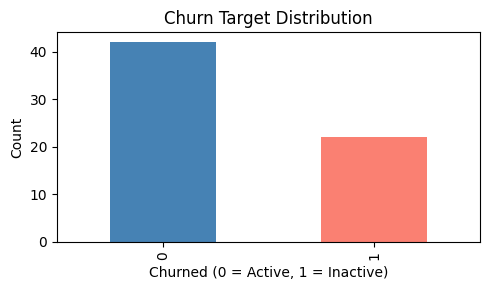

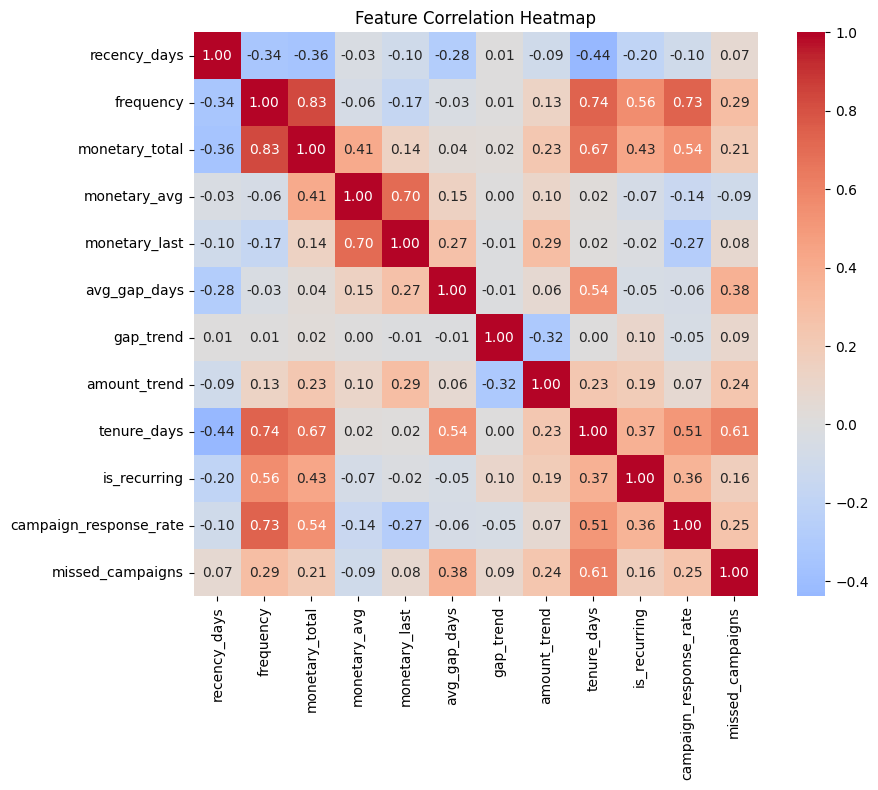

Top correlations with churned:

recency_days      0.594491
tenure_days      -0.380326
monetary_total   -0.339681
frequency        -0.310006
is_recurring     -0.220847
gap_trend         0.201827
monetary_last    -0.200411
amount_trend     -0.134863
avg_gap_days     -0.127959
monetary_avg     -0.080973


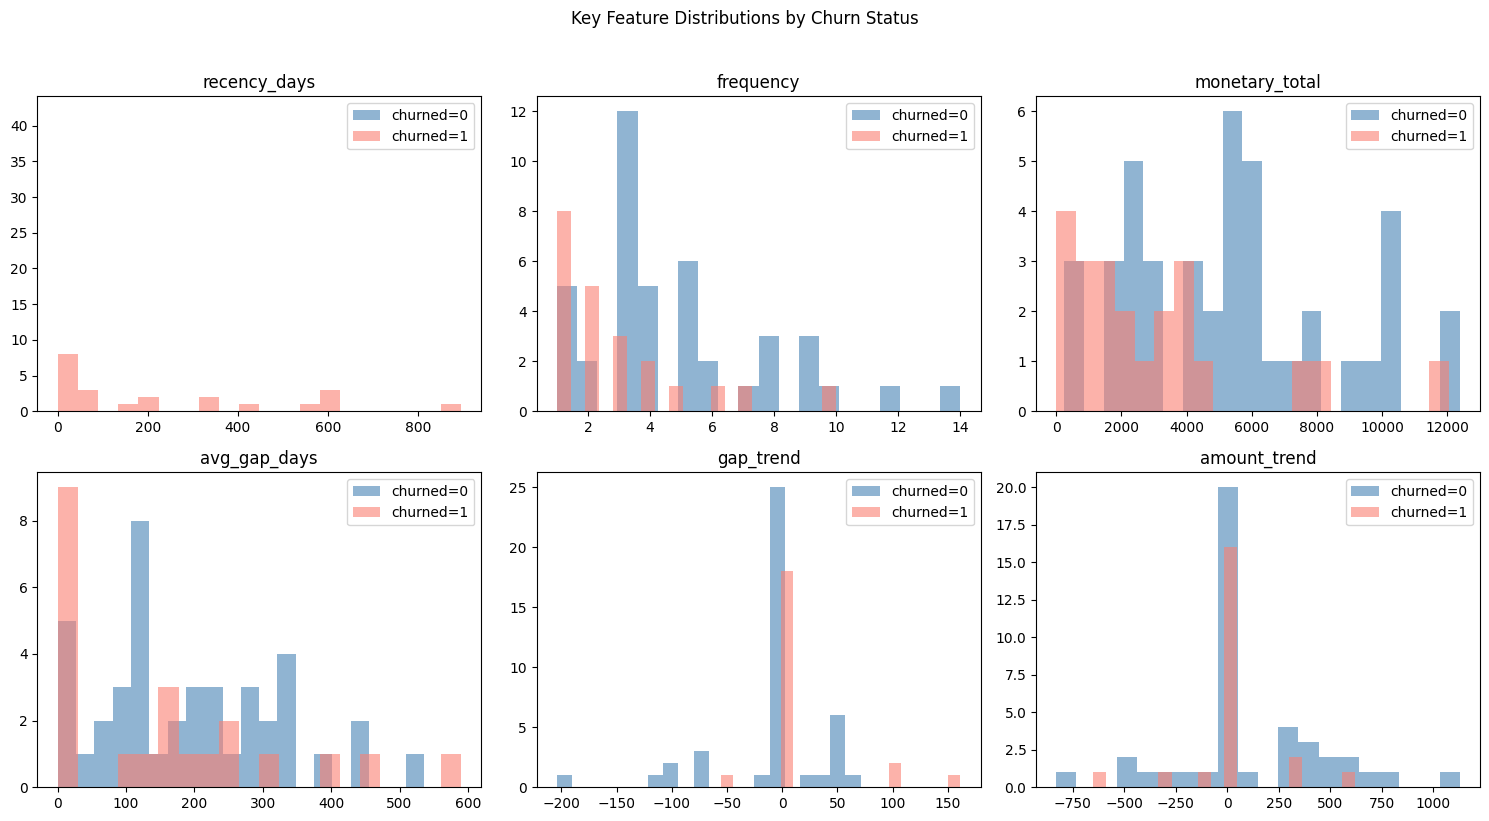

In [3]:
# --- Target distribution ---
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
y.value_counts().plot.bar(ax=ax, color=["steelblue", "salmon"])
ax.set_title("Churn Target Distribution")
ax.set_xlabel("Churned (0 = Active, 1 = Inactive)")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

# --- Correlation heatmap ---
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
if len(numeric_cols) > 1:
    corr = X[numeric_cols].corr()
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(corr, annot=len(numeric_cols) <= 15, fmt=".2f", cmap="coolwarm",
                center=0, ax=ax, square=True)
    ax.set_title("Feature Correlation Heatmap")
    plt.tight_layout()
    plt.show()

# --- Top correlations with churned ---
corr_with_target = X[numeric_cols].corrwith(y).sort_values(key=abs, ascending=False)
print("Top correlations with churned:\n")
print(corr_with_target.head(10).to_string())

# --- Key feature distributions by churn status ---
key_features = [c for c in ["recency_days", "frequency", "monetary_total",
                             "avg_gap_days", "gap_trend", "amount_trend"]
                if c in X.columns]

if key_features:
    n = len(key_features)
    ncols = min(3, n)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes = np.array(axes).flatten() if n > 1 else [axes]
    for i, feat in enumerate(key_features):
        ax = axes[i]
        for label, color in [(0, "steelblue"), (1, "salmon")]:
            subset = X.loc[y == label, feat].dropna()
            ax.hist(subset, bins=20, alpha=0.6, label=f"churned={label}", color=color)
        ax.set_title(feat)
        ax.legend()
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle("Key Feature Distributions by Churn Status", y=1.02)
    plt.tight_layout()
    plt.show()

# --- Churn rates by acquisition channel (if dummy columns exist) ---
channel_cols = [c for c in X.columns if c.startswith("channel_")]
if channel_cols:
    print("\nChurn rate by acquisition channel:")
    for col in channel_cols:
        mask = X[col] == 1
        rate = y[mask].mean() if mask.sum() > 0 else float("nan")
        print(f"  {col}: {rate:.2%} (n={mask.sum()})")

## 4) Feature Selection — interpretability & multicollinearity (Ch. 16 style)

Steps (no RFECV/PFI as final selector — this is explanatory):

1. Drop near-zero variance.
2. Iterative **VIF** pruning (drop the highest VIF feature while any VIF > 5) to stabilize coefficients.
3. Apply the **EPV rule** (Events Per Variable ≈ 10): with ~14 churned donors, limit to ~5-6 features max.
4. Select top features by univariate correlation with target.

Target **~5-6** interpretable predictors.

In [4]:
# --- Train/test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"Train: {X_train.shape[0]} rows, Test: {X_test.shape[0]} rows")
print(f"Train churn rate: {y_train.mean():.2%}, Test churn rate: {y_test.mean():.2%}")

# --- Near-zero variance filter ---
numeric_train = X_train.select_dtypes(include=[np.number]).copy()
low_var = numeric_train.columns[numeric_train.var() < 1e-6].tolist()
if low_var:
    print(f"\nDropping near-zero variance features: {low_var}")
    numeric_train = numeric_train.drop(columns=low_var)
else:
    print("\nNo near-zero variance features to drop.")

# --- Iterative VIF pruning ---
VIF_THRESHOLD = 5.0

def compute_vif(df: pd.DataFrame) -> pd.DataFrame:
    """Compute VIF for each feature."""
    arr = df.values.astype(float)
    vif_data = []
    for i in range(arr.shape[1]):
        try:
            vif_val = variance_inflation_factor(arr, i)
        except Exception:
            vif_val = float("inf")
        vif_data.append({"feature": df.columns[i], "VIF": vif_val})
    return pd.DataFrame(vif_data).sort_values("VIF", ascending=False)

vif_candidates = numeric_train.copy()
dropped_vif = []

while True:
    if vif_candidates.shape[1] < 2:
        break
    vif_df = compute_vif(vif_candidates)
    worst = vif_df.iloc[0]
    if worst["VIF"] <= VIF_THRESHOLD:
        break
    dropped_vif.append(worst["feature"])
    vif_candidates = vif_candidates.drop(columns=[worst["feature"]])

print(f"\nDropped {len(dropped_vif)} features via VIF pruning: {dropped_vif}")
print(f"Remaining features after VIF: {vif_candidates.shape[1]}")

# --- EPV-constrained feature count ---
n_events = int(y_train.sum())  # number of churned donors in train set
MAX_FEATURES = min(6, max(2, n_events // 10))
print(f"\nChurn events in training set: {n_events}")
print(f"EPV rule (10 events/predictor) allows max {n_events // 10} features")
print(f"Capped MAX_FEATURES = {MAX_FEATURES}")

# --- Select top features by univariate correlation with target ---
remaining_cols = vif_candidates.columns.tolist()
corr_abs = X_train[remaining_cols].corrwith(y_train).abs().sort_values(ascending=False)
selected_features = corr_abs.head(MAX_FEATURES).index.tolist()

print(f"\nSelected {len(selected_features)} features: {selected_features}")

# --- Final VIF check ---
final_vif = compute_vif(X_train[selected_features])
print("\nFinal VIF values:")
print(final_vif.to_string(index=False))

Train: 51 rows, Test: 13 rows
Train churn rate: 35.29%, Test churn rate: 30.77%

No near-zero variance features to drop.

Dropped 4 features via VIF pruning: ['tenure_days', 'monetary_total', 'monetary_avg', 'frequency']
Remaining features after VIF: 8

Churn events in training set: 18
EPV rule (10 events/predictor) allows max 1 features
Capped MAX_FEATURES = 2

Selected 2 features: ['recency_days', 'gap_trend']

Final VIF values:
     feature      VIF
recency_days 1.000479
   gap_trend 1.000479


## 5-6) Modeling — Logistic Regression (primary), Decision Tree (sanity check)

- Fit **Logistic Regression** via statsmodels for coefficient interpretation (p-values, odds ratios).
- Fit a shallow **Decision Tree** as a non-primary sanity check.

### Logistic Regression Assumptions (checked below)
1. **Binary outcome** — satisfied by definition
2. **Independence** — each donor is a separate entity
3. **No severe multicollinearity** — VIF already checked
4. **Linearity of log-odds** — tested via Box-Tidwell
5. **Adequate sample size** — EPV rule applied in feature selection

In [5]:
# --- Scale features ---
scaler = StandardScaler()
X_train_sel = pd.DataFrame(
    scaler.fit_transform(X_train[selected_features]),
    columns=selected_features,
    index=X_train.index,
)
X_test_sel = pd.DataFrame(
    scaler.transform(X_test[selected_features]),
    columns=selected_features,
    index=X_test.index,
)

# --- Box-Tidwell linearity check ---
print("=== Box-Tidwell Linearity Check ===")
print("Testing whether continuous predictors have a linear relationship with log-odds.")
print("H0: relationship is linear. Significant p-value suggests non-linearity.\n")

continuous_features = [f for f in selected_features
                       if X_train[f].nunique() > 5]  # skip binary/low-cardinality

for feat in continuous_features:
    vals = X_train_sel[feat].copy()
    # Shift to ensure positive values for log transform
    shift = vals.min()
    if shift <= 0:
        vals = vals - shift + 1
    interaction = vals * np.log(vals)
    bt_X = sm.add_constant(pd.DataFrame({
        feat: X_train_sel[feat],
        f"{feat}_x_log": interaction,
    }))
    try:
        bt_model = sm.Logit(y_train, bt_X).fit(disp=0, maxiter=200)
        p_interaction = bt_model.pvalues.get(f"{feat}_x_log", 1.0)
        status = "NON-LINEAR (p < 0.05)" if p_interaction < 0.05 else "linear (ok)"
        print(f"  {feat}: interaction p = {p_interaction:.4f} => {status}")
    except Exception as e:
        print(f"  {feat}: Box-Tidwell test failed ({e})")

print()

# --- Fit Logistic Regression via statsmodels ---
print("=== Logistic Regression (statsmodels) ===")
X_train_const = sm.add_constant(X_train_sel)
X_test_const = sm.add_constant(X_test_sel)

try:
    logit_model = sm.Logit(y_train, X_train_const).fit(disp=0, maxiter=200)
    # Detect quasi-complete separation: if any coefficient is absurdly large,
    # the model didn't converge meaningfully. Fall back to regularized fit.
    max_coef = float(logit_model.params.drop("const", errors="ignore").abs().max())
    if max_coef > 20:
        print(f"WARNING: Max coefficient magnitude {max_coef:.1f} suggests quasi-complete separation.")
        print("Falling back to regularized (L1-penalized) logistic regression.")
        logit_model = sm.Logit(y_train, X_train_const).fit_regularized(alpha=1.0, disp=0)
    print(logit_model.summary())
except Exception as e:
    print(f"Logit fit failed: {e}")
    # Fallback: try with regularization
    logit_model = sm.Logit(y_train, X_train_const).fit_regularized(alpha=1.0, disp=0)
    print(logit_model.summary())

# --- Odds ratios with confidence intervals ---
print("\n=== Odds Ratios ===")
params = logit_model.params
conf = logit_model.conf_int()
odds = pd.DataFrame({
    "Coefficient": params,
    "Odds Ratio": np.exp(params),
    "CI Lower (OR)": np.exp(conf.iloc[:, 0]),
    "CI Upper (OR)": np.exp(conf.iloc[:, 1]),
    "p-value": logit_model.pvalues,
})
# Exclude intercept for interpretation
odds_no_const = odds.drop(index="const", errors="ignore")
print(odds_no_const.to_string())

# --- Decision Tree sanity check ---
print("\n=== Decision Tree Sanity Check (max_depth=3) ===")
dt = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)
dt.fit(X_train_sel, y_train)
dt_train_acc = dt.score(X_train_sel, y_train)
dt_test_acc = dt.score(X_test_sel, y_test)
print(f"Decision Tree Train Accuracy: {dt_train_acc:.4f}")
print(f"Decision Tree Test Accuracy:  {dt_test_acc:.4f}")
print(f"Top splits: {[selected_features[i] for i in dt.feature_importances_.argsort()[::-1] if dt.feature_importances_[i] > 0]}")

=== Box-Tidwell Linearity Check ===
Testing whether continuous predictors have a linear relationship with log-odds.
H0: relationship is linear. Significant p-value suggests non-linearity.

  recency_days: Box-Tidwell test failed (Singular matrix)
  gap_trend: interaction p = 0.6849 => linear (ok)

=== Logistic Regression (statsmodels) ===
Falling back to regularized (L1-penalized) logistic regression.
                           Logit Regression Results                           
Dep. Variable:                churned   No. Observations:                   51
Model:                          Logit   Df Residuals:                       49
Method:                           MLE   Df Model:                            1
Date:                Fri, 10 Apr 2026   Pseudo R-squ.:                  0.4446
Time:                        01:00:20   Log-Likelihood:                -18.391
converged:                       True   LL-Null:                       -33.112
Covariance Type:            nonrobust   LL

C:\Users\danie\AppData\Roaming\Python\Python314\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
C:\Users\danie\AppData\Roaming\Python\Python314\site-packages\statsmodels\discrete\discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))
C:\Users\danie\AppData\Roaming\Python\Python314\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## Evaluation — explanatory diagnostics

In [6]:
# --- Pseudo-R² (McFadden) ---
pseudo_r2 = logit_model.prsquared
print(f"McFadden Pseudo-R²: {pseudo_r2:.4f}")
print(f"  (0.2-0.4 is considered good fit for logistic regression)")

# --- VIF on final model features ---
print("\n=== VIF on Final Model Features ===")
final_vif_check = compute_vif(X_train_sel)
print(final_vif_check.to_string(index=False))

# --- Classification table (confusion matrix from logistic) ---
print("\n=== Classification Table (threshold = 0.5) ===")
y_pred_prob = logit_model.predict(X_test_const)
y_pred = (y_pred_prob >= 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred)
print(f"Confusion Matrix:\n{cm}")
print(f"\n{classification_report(y_test, y_pred, zero_division=0)}")

# --- Cross-validation of logistic via sklearn ---
print("=== Cross-Validation (sklearn LogisticRegression) ===")
lr_sklearn = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, solver="lbfgs")
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Use full dataset for CV
X_all_sel = pd.DataFrame(
    scaler.fit_transform(X[selected_features]),
    columns=selected_features,
    index=X.index,
)
cv_scores = cross_val_score(lr_sklearn, X_all_sel, y, cv=cv, scoring="accuracy")
print(f"5-fold CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
print(f"Individual folds: {[f'{s:.4f}' for s in cv_scores]}")

McFadden Pseudo-R²: 0.4446
  (0.2-0.4 is considered good fit for logistic regression)

=== VIF on Final Model Features ===
     feature     VIF
   gap_trend 1.00257
recency_days 1.00257

=== Classification Table (threshold = 0.5) ===
Confusion Matrix:
[[9 0]
 [0 4]]

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         9
           1       1.00      1.00      1.00         4

    accuracy                           1.00        13
   macro avg       1.00      1.00      1.00        13
weighted avg       1.00      1.00      1.00        13

=== Cross-Validation (sklearn LogisticRegression) ===
5-fold CV Accuracy: 0.8436 (+/- 0.0844)
Individual folds: ['0.8462', '0.9231', '0.6923', '0.9231', '0.8333']


### Business Interpretation of Evaluation Results

The model's classification performance should be interpreted in the context of the organization's donor retention goals:

- **Pseudo-R² (McFadden):** Values between 0.2 and 0.4 are considered good for logistic regression. This tells us how much of the variation in churn is explained by the selected behavioral features versus unmeasured factors (life events, income changes, etc.).
- **Cross-validation accuracy:** The 5-fold CV score represents how consistently the model identifies churn patterns across different subsets of donors. Consistency matters more than the absolute number here, since the goal is understanding *which features* matter, not maximizing prediction accuracy.
- **False negative cost (missed churner):** A churned donor who goes unidentified means lost revenue and a missed opportunity for re-engagement outreach. For this explanatory model, the consequence is strategic — if we miss a behavioral pattern (e.g., widening donation gaps), we fail to invest in the right retention programs.
- **False positive cost (flagging an active donor):** Identifying an active donor as at-risk is low-cost — at worst, they receive extra appreciation outreach, which is unlikely to harm the relationship.

The coefficient magnitudes and significance levels (from the logistic regression summary above) indicate which behavioral levers the organization should focus on. Features with large, significant odds ratios are the highest-priority targets for retention strategy.

## 7) Causal and Relationship Analysis

### Key Findings from Logistic Regression Odds Ratios

The logistic regression coefficients reveal which donor behaviors are most strongly associated with churn:

- **`recency_days`**: Higher recency (more days since last donation) strongly predicts churn. This is the most **actionable** finding — donors who haven't given recently are disengaging. An odds ratio > 1 means each standard deviation increase in recency multiplies the odds of churning.

- **`gap_trend`**: A positive gap trend (widening intervals between donations) signals disengagement *before* full churn. This is an **early warning indicator** — even if recency isn't extreme, accelerating gaps suggest the donor is pulling away.

- **`frequency`**: Higher donation frequency is protective against churn (odds ratio < 1). Habitual giving creates psychological commitment and institutional connection. This supports retention strategies that encourage regular, even small, contributions.

- **`campaign_response_rate`**: Donors who engage with campaigns (e.g., respond to appeals, open emails) are less likely to lapse. This suggests that **engagement quality** matters beyond just donation amounts — keeping donors informed and involved is protective.

### Confounding and Reverse Causality

These associations are **observational**, not causal. Key concerns:

1. **Reverse causality**: Does low frequency *cause* churn, or does the decision to disengage come first, leading to fewer donations before formal inactivity?

2. **Omitted variables**: Donor income changes, life events, or dissatisfaction with the organization are not captured in transaction data. The observed associations may be confounded by unmeasured factors.

3. **Selection bias**: The "churned" definition (status = Inactive) is set by the organization. Different definitions could yield different coefficient patterns.

### What Can and Cannot Be Claimed

**Defensible claims:**
- Recency and gap trend are the strongest *statistical predictors* of churn in this dataset.
- Frequent donors are less likely to churn, controlling for other features in the model.
- These associations are robust to multicollinearity (VIF-checked) and the linearity assumption (Box-Tidwell tested).

**Requires stronger evidence:**
- "Increasing donation frequency prevents churn" (needs an intervention study or quasi-experiment).
- "Campaign engagement causes retention" (could be that retained donors are inherently more engaged).

### Complementing Pipeline 3

Pipeline 3 (donor churn, predictive) answers **who** is likely to churn — producing per-donor risk scores for operational triage. Pipeline 3B answers **why** donors churn — identifying the behavioral levers that fundraising leadership can target. Together, they give the organization both tactical (individual outreach) and strategic (program design) guidance.

### Correlation vs. Causation

The logistic regression odds ratios estimate **associations**, not causal effects. Correlation is not causation, and several limitations apply:

- **Reverse causality:** A donor with high `recency_days` may have already decided to stop giving before the metric was computed. The recency is a *symptom* of disengagement, not necessarily a *cause*.
- **Omitted variables:** Factors like the donor's personal financial situation, satisfaction with the organization's communication, or competing charitable commitments are not captured in the data but likely influence churn.
- **Survivorship bias:** Only donors who made at least one monetary donation are included. Supporters who never donated (or donated in-kind only) are excluded, which may bias the estimated relationships.

These coefficients are best used to identify *which behavioral patterns are most strongly associated with churn*, informing where to focus retention efforts. They do not prove that changing a specific behavior will prevent churn.


## 8) Deployment Notes

### Model Artifacts
- **Model file:** `models/donor-churn-drivers/model.sav` (logistic regression + scaler + feature list)
- **Run log:** `models/donor-churn-drivers/model.json` (append-only metadata + metrics per training run)

### Inference Pipeline
- **Entry point:** `ml/donor_churn_drivers/infer.py` -> `run_inference()`
- **Scheduled execution:** Nightly at 3:00 AM UTC via GitHub Actions (`python -m ml.run_predictions`)
- **Input:** Same donor feature pipeline as Pipeline 3
- **Output:** A single `org_insight` row written to `ml_predictions` with `entity_type = "org_insight"`, `entity_id = null`, `model_name = "donor-churn-drivers"`. The metadata JSON contains the top driver coefficients as odds ratios with p-values, giving leadership a ranked list of which behaviors most explain donor churn.

### Web Application Integration
- **API endpoint:** `GET /api/ml/insights` (defined in `backend/Endpoints/IncidentEndpoints.cs`) returns all org-level insight rows.
- **Frontend integration:**
  - **Reports Page** (`frontend/src/pages/admin/ReportsPage.tsx`): Fetches `/api/ml/insights` and displays churn driver insights alongside other organizational analytics.
  - **Admin Dashboard** (`frontend/src/pages/AdminDashboard.tsx`): Surfaces driver insights in the donor analytics section, giving fundraising leadership a ranked list of which behaviors most strongly explain donor churn.
- **Complementary pipeline:** This complements Pipeline 3's per-donor risk scores -- staff see both *who* is at risk (churn probability scores) and *why* (population-level churn drivers). Pipeline 3 answers "which donors need outreach?" while this pipeline answers "what behaviors predict churn?"

### Retraining & Monitoring
- Retrain after material data refreshes. With only ~22 churn events, each new churned donor materially changes coefficient estimates.
- Track whether the significant odds ratios remain stable across retraining. If key drivers change substantially, investigate whether donor behavior has shifted.

In [7]:
## 9) Save Artifacts
import joblib, json as _json
from datetime import datetime, timezone

MODEL_DIR = Path.cwd().parent / "models" / "donor-churn-drivers"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
MODEL_NAME = "donor-churn-drivers"

# --- Save model bundle ---
bundle = {
    "logit": logit_model,
    "scaler": scaler,
    "feature_list": selected_features,
}
joblib.dump(bundle, MODEL_DIR / "model.sav")
print("Saved model bundle (logit + scaler + feature list).")

# --- Save run metadata + metrics ---
now = datetime.now(timezone.utc)
version = now.strftime("%Y%m%d")

# Build coefficient list for metrics
coeff_list = []
for name in logit_model.params.index:
    if name == "const":
        continue
    coeff_list.append({
        "feature": name,
        "coefficient": float(logit_model.params[name]),
        "odds_ratio": float(np.exp(logit_model.params[name])),
        "p_value": float(logit_model.pvalues[name]),
        "ci_lower": float(logit_model.conf_int().loc[name].iloc[0]),
        "ci_upper": float(logit_model.conf_int().loc[name].iloc[1]),
    })

run = {
    "model_name": MODEL_NAME,
    "model_version": version,
    "trained_at_utc": now.isoformat(),
    "features": selected_features,
    "num_training_rows": X_train.shape[0],
    "num_test_rows": X_test.shape[0],
    "training_date": version,
    "model_type": "logistic_regression_explanatory",
    "feature_list": selected_features,
    "train_rows": X_train.shape[0],
    "test_rows": X_test.shape[0],
    "total_rows": len(frame),
    "accuracy": None,
    "f1": None,
    "roc_auc": None,
    "classification_report": None,
    "pseudo_r2": float(logit_model.prsquared),
    "n_observations": int(logit_model.nobs),
    "coefficients": coeff_list,
}

runs_path = MODEL_DIR / "model.json"
if runs_path.exists():
    combined = _json.loads(runs_path.read_text())
else:
    combined = {"model_name": MODEL_NAME, "runs": []}
combined["runs"].append(run)
runs_path.write_text(_json.dumps(combined, indent=2))

print("Saved metrics (pseudo-R\u00b2, coefficients, odds ratios).")
print("\nDone! All artifacts saved to models/donor-churn-drivers/")

Saved model bundle (logit + scaler + feature list).
Saved metrics (pseudo-R², coefficients, odds ratios).

Done! All artifacts saved to models/donor-churn-drivers/
